# Bài 8: Bài toán phân cụm

In [ ]:
import numpy as np
import random, os
from IPython import display

import matplotlib.pyplot as plt          # vẽ hình
from collections import Counter

import pandas as pd
from sklearn.datasets import make_blobs  # tạo tập điểm phân bố Gaussian
from sklearn.cluster import KMeans       # thuật toán phân cụm k-means

import warnings
warnings.filterwarnings("ignore")

# cố định random-state để phục hồi lại kết quả thí nghiệm
random_state = 42
random.seed(random_state)
os.environ['PYTHONHASHSEED'] = str(random_state)
np.random.seed(random_state)

## Bài 3. Bài tập áp dụng

Áp dụng thuật toán k-means cho tập dữ liệu sau:
+ Tập điểm dữ liệu $X_2$ gồm 400 điểm 2 chiều chứa 4 lớp với số lượng phần tử bằng nhau. Các tập hợp điểm trong lớp tuân theo phân phối Gaussian với means $m_0=\left(0, 0\right)$, $m_1=\left(4, 0\right)$, $m_2=\left(0, 4\right)$, và $m_3=\left(5, 4\right)$ với các covariance matrices tương ứng $S_0=I$, $S_1=1.5I$, $S_2=1.1I$, $S_3=0.5I$.


### 1. Tạo và hiển thị dữ liệu

In [6]:
# Sinh tập hợp điểm theo phân phối Gaussian
X2, y2 = make_blobs(n_samples    = 400,                         # số lượng điểm
                    centers      = [[0,0], [4,0],[0,4],[5,4]], # vị trí tâm
                    cluster_std  = [1, 1.5, 1.1, 0.5],          # độ phân tán
                    random_state = random_state,                # seed ngẫu nhiên
                   )

In [7]:
# lưu trữ trong pandas
df_points = pd.DataFrame(X2, columns=["x", "y"])
df_points["label"] = y2

# tính số lớp, tần số xuất hiện mỗi lớp
n_classes = len(np.unique(df_points["label"])) # tính số lớp dữ liệu
labels, cnts = np.unique(df_points["label"], return_counts=True)
n_cnts = dict(zip(labels, cnts))
print(f'+ labels={labels}\n+ cnts={cnts}\n+ n_cnts={n_cnts}')

# hiển thị dữ liệu
display.display(df_points)

+ labels=[0 1 2 3]
+ cnts=[100 100 100 100]
+ n_cnts={np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}


,x,y,label
0,0.372346,3.543183,2
1,-0.495072,4.685135,2
2,4.738638,4.524505,3
3,5.014159,4.014878,3
4,4.505198,3.937107,3
...,...,...,...
395,5.120940,0.915555,1
396,5.022929,-0.465400,1
397,-1.150994,0.375698,0
398,-2.718809,3.123415,2


Center 0: [-0.11556425  0.03402232]
Center 1: [4.19237309 0.06523147]
Center 2: [-0.04954113  3.86110005]
Center 3: [4.96175896 4.04720768]


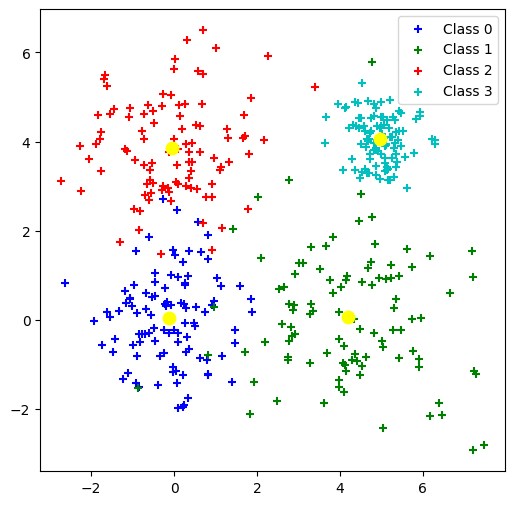

In [8]:
# màu của từng lớp
colors = {0:'b', 1:'g',2:'r',3:'c', 4:'m', 5:'y', 6:'k', 7:'w'} 

# vẽ tập dữ liệu điểm
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(n_classes):
    # tính toán điểm trung tâm từng lớp
    p_center = np.mean(X2[y2==i], axis = 0) 
    print(f'Center {i}: {p_center}')
    # vẽ tập điểm
    plt.scatter(X2[y2==i, 0], X2[y2==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(p_center[0], p_center[1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

### 2. Áp dụng thuật toán phân cụm

####  2.1. Số cụm m = 4 ngẫu nhiên

In [9]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X2); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels  = sum(y2 == y_pred) # tính độ chính xác

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

Centers:
[[-0.01782931 -0.04253637]
 [ 4.91382944  4.02072054]
 [-0.03778918  3.84393915]
 [ 4.51504729 -0.10687236]]
Inertia: 746.5032722384981
Correct Labels: 198 / 400
Accuracy score: 0.49


Predict: [2 2 1 1 1 1 1 3 0 0 2 0 1 0 2 0 2 3 0 3] ...
Center 0: [-0.01782931 -0.04253637]
Center 1: [4.91382944 4.02072054]
Center 2: [-0.03778918  3.84393915]
Center 3: [ 4.51504729 -0.10687236]


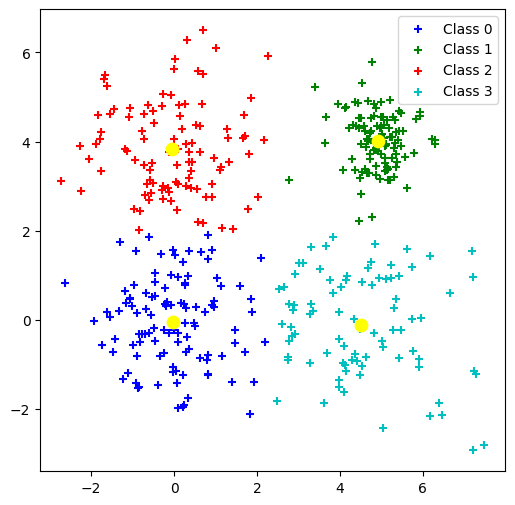

In [10]:
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X2[y_pred==i, 0], X2[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

####  2.2. Số cụm m = 3 ngẫu nhiên

Centers:
[[ 0.86424309 -0.20131147]
 [ 5.00623156  2.78709335]
 [-0.0783468   3.7996709 ]]
Inertia: 1493.7691758748476
Correct Labels: 248 / 400
Accuracy score: 0.62

Predict: [2 2 1 1 1 1 1 1 0 0 2 0 1 0 2 0 2 1 0 1] ...
Center 0: [ 0.86424309 -0.20131147]
Center 1: [5.00623156 2.78709335]
Center 2: [-0.0783468  3.7996709]


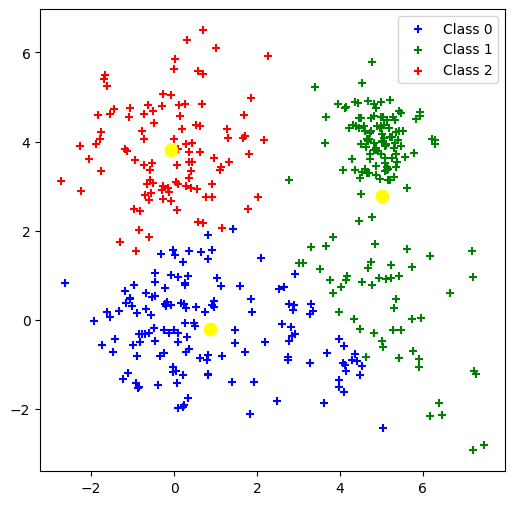

In [11]:
m = 3 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X2); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y2 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X2[y_pred==i, 0], X2[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.3. Số cụm m = 5 ngẫu nhiên

Centers:
[[ 2.43558582  0.41694065]
 [ 4.91382944  4.02072054]
 [-0.10538557  3.90631528]
 [ 5.15185818 -0.29614824]
 [-0.27206289 -0.06067086]]
Inertia: 638.6381207490174
Correct Labels: 108 / 400
Accuracy score: 0.27

Predict: [2 2 1 1 1 1 1 3 4 4 2 4 1 4 2 4 2 0 4 3] ...
Center 0: [2.43558582 0.41694065]
Center 1: [4.91382944 4.02072054]
Center 2: [-0.10538557  3.90631528]
Center 3: [ 5.15185818 -0.29614824]
Center 4: [-0.27206289 -0.06067086]


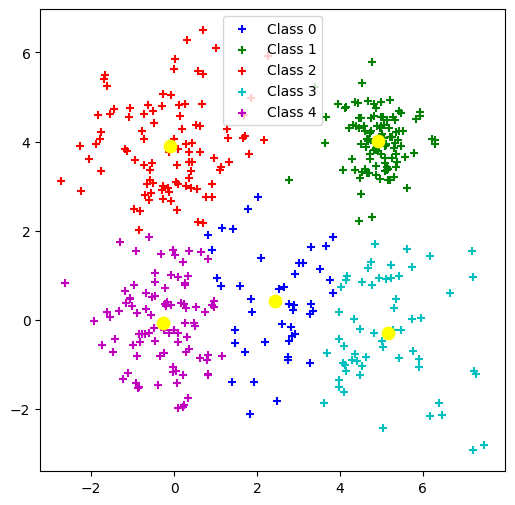

In [12]:
m = 5 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, random_state=random_state) # thuật toán kmean
kmeans.fit(X2); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y2 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X2[y_pred==i, 0], X2[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

#### 2.4. Số cụm m = 4 xác định trước

Centers:
[[-0.01782931 -0.04253637]
 [ 4.91382944  4.02072054]
 [ 4.51504729 -0.10687236]
 [-0.03778918  3.84393915]]
Inertia: 746.5032722384981
Correct Labels: 102 / 400
Accuracy score: 0.26

Predict: [3 3 1 1 1 1 1 2 0 0 3 0 1 0 3 0 3 2 0 2] ...
Center 0: [-0.01782931 -0.04253637]
Center 1: [4.91382944 4.02072054]
Center 2: [ 4.51504729 -0.10687236]
Center 3: [-0.03778918  3.84393915]


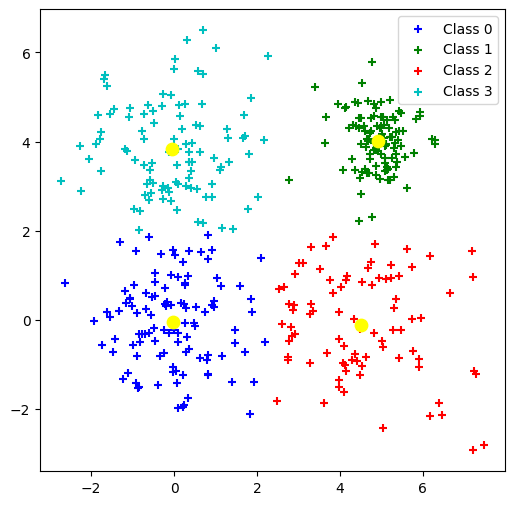

In [14]:
m = 4 # số cụm khởi tạo
kmeans = KMeans(n_clusters=m, 
                init = np.array([[-2,-2], [-2.1, -2.1], [-2.0, -2.2], [-2.1,-2.2]]),
                n_init = 1, # chỉ chạy 1 lần k_means
                random_state=random_state) # thuật toán kmean
kmeans.fit(X2); # huấn luyện tìm m cluster

cluster_centers = kmeans.cluster_centers_
cluster_inertia = kmeans.inertia_

# kiểm tra số mẫu phân lớp đúng
y_pred          = kmeans.labels_
correct_labels = sum(y2 == y_pred)

print(f'Centers:\n{cluster_centers}')
print(f'Inertia: {cluster_inertia}')
print(f'Correct Labels: {correct_labels} / {len(df_points)}')
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(len(df_points))))

print()
print(f'Predict: {y_pred[0:20]} ...')
# vẽ tập dữ liệu điểm dự đoán
plt.figure(figsize=(6,6))     # độ lớn của khung vẽ
for i in range(m):
    # Điểm trung tâm của lớp
    print(f'Center {i}: {cluster_centers[i]}')
    
    # vẽ tập điểm
    plt.scatter(X1[y_pred==i, 0], X1[y_pred==i, 1], marker='+', 
                c = colors[i], label = f"Class {i}")
    # vẽ tâm
    plt.scatter(cluster_centers[i, 0], cluster_centers[i, 1], marker='o', 
                c='yellow', s = 80)
    pass # for
plt.legend()
plt.show()

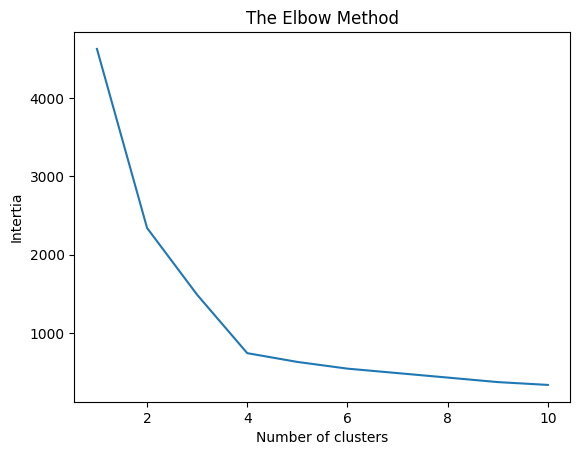

In [16]:
list_intertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i,      # số cluster
                    init = 'k-means++',  # khởi tạo ngẫu nhiên dùng k-means++
                    max_iter = 300,      # số lần lặp trong thuật toán
                    n_init = 10,         # số lần chạy lại k-means và lấy tốt nhất
                    random_state = random_state,
                   )
    kmeans.fit(X2)
    list_intertia.append(kmeans.inertia_)
plt.plot(range(1, 11), list_intertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

# Kết thúc
